# SI Demo — "Visit Jordan" Tourism KPI Dashboard

**Domain:** Jordanian Tourism (Petra, Dead Sea, Wadi Rum, Jerash, Aqaba)  
**Purpose:** This notebook mirrors the Module 4 learner assignment pattern:

| Step | What happens |
|------|--------------|
| 1 | Extract data from a CSV (no database needed for demo) |
| 2 | Define and compute 3 KPIs |
| 3 | Run a Welch's t-test |
| 4 | Build a multi-panel Matplotlib/Seaborn dashboard |
| 5 | Print a 3-sentence executive summary |

---

## Cell 1 — Imports & Global Settings

We import every library we need at the top of the notebook so dependencies are explicit and easy to audit.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress pandas FutureWarnings that clutter the output
warnings.filterwarnings("ignore", category=FutureWarning)

# Where chart PNGs will be saved
OUTPUT_DIR = os.path.join(os.getcwd(), "demo_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Apply a consistent seaborn theme across every plot in this notebook
sns.set_theme(style="whitegrid", palette="muted")

# Render matplotlib figures inline in the notebook
%matplotlib inline

print("Libraries loaded successfully.")
print(f"Output directory: {OUTPUT_DIR}")

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


Libraries loaded successfully.
Output directory: /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/demo_output


---
## Cell 2 — Generate the Synthetic Dataset

Because this is a demo, we build a realistic-looking dataset from scratch using a seeded random number generator.

**Design decisions encoded in the data:**
- **Sites:** Petra, Dead Sea, Wadi Rum, Jerash, Aqaba — Jordan's five flagship destinations
- **Time:** 24 months (Jan 2024 – Dec 2025)
- **Visitor origin split:** Arab 35 %, European 25 %, North American 18 %, Asian 14 %, Other 8 %
- **Ticket types:** individual, group, student
- **Seasonality:** cosine curve peaking in spring (April) and autumn

In [2]:
def generate_tourism_data():
    """
    Simulate 2 years of monthly visitor data for 5 Jordanian sites.
    Saves result to tourism_data.csv so learners can inspect the raw data.
    """
    # Fixed seed guarantees the same numbers every run
    rng = np.random.default_rng(42)

    sites        = ["Petra", "Dead Sea", "Wadi Rum", "Jerash", "Aqaba"]
    months       = pd.date_range("2024-01", periods=24, freq="ME")   # 24 month-end timestamps
    origins      = ["Arab", "European", "North American", "Asian", "Other"]
    ticket_types = ["individual", "group", "student"]

    # --- Seasonal multiplier (cosine wave) ---
    # month_num=4 (April) is the primary peak; returns values between 0.6 and 1.4
    def seasonal(month_num):
        return 1.0 + 0.4 * np.cos((month_num - 4) * np.pi / 6)

    # Monthly baseline visitor count for each site
    base_visitors = {"Petra": 12000, "Dead Sea": 8000, "Wadi Rum": 6000,
                     "Jerash": 4000,  "Aqaba":  7000}

    # Average daily spend per visitor (JD) for each site
    base_spend = {"Petra": 85, "Dead Sea": 70, "Wadi Rum": 95,
                  "Jerash": 55, "Aqaba": 65}

    rows = []

    for month in months:
        m = month.month                                  # integer 1–12

        for site in sites:
            for origin in origins:
                for ttype in ticket_types:

                    # Market share of each origin region
                    origin_mult = {"Arab": 0.35, "European": 0.25,
                                   "North American": 0.18, "Asian": 0.14, "Other": 0.08}

                    # Share of visitors buying each ticket type
                    ttype_mult  = {"individual": 0.50, "group": 0.35, "student": 0.15}

                    # Final visitor count = base × season × origin share × ticket share × noise
                    visitors = int(
                        base_visitors[site]
                        * seasonal(m)
                        * origin_mult[origin]
                        * ttype_mult[ttype]
                        * rng.uniform(0.85, 1.15)        # ±15 % random noise
                    )

                    # Spending adjustments by ticket type
                    spend_adj = {"individual": 1.0, "group": 1.20, "student": 0.70}
                    avg_spend = round(
                        base_spend[site] * spend_adj[ttype] * rng.uniform(0.90, 1.10), 2
                    )

                    rows.append({
                        "month":            month.strftime("%Y-%m"),
                        "site":             site,
                        "visitor_count":    visitors,
                        "avg_spending_jod": avg_spend,
                        "origin_region":    origin,
                        "ticket_type":      ttype,
                    })

    df = pd.DataFrame(rows)
    csv_path = os.path.join(os.getcwd(), "tourism_data.csv")
    df.to_csv(csv_path, index=False)
    print(f"Dataset generated: {len(df):,} rows → {csv_path}")
    return df


# --- Generate (or regenerate) the dataset ---
df_raw = generate_tourism_data()
df_raw.head(10)

Dataset generated: 1,800 rows → /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/tourism_data.csv


,month,site,visitor_count,avg_spending_jod,origin_region,ticket_type
0,2024-01,Petra,2272,83.96,Arab,individual
1,2024-01,Petra,1628,106.03,Arab,group
2,2024-01,Petra,553,65.16,Arab,student
3,2024-01,Petra,1617,89.86,European,individual
4,2024-01,Petra,932,100.99,European,group
5,2024-01,Petra,432,64.58,European,student
6,2024-01,Petra,1126,90.49,North American,individual
7,2024-01,Petra,743,96.44,North American,group
8,2024-01,Petra,329,54.31,North American,student
9,2024-01,Petra,922,87.24,Asian,individual


---
## Cell 3 — Load & Inspect the Data
We reload the file we just wrote so this cell works independently.

In [3]:
def load_data():
    csv_path = os.path.join(os.getcwd(), "tourism_data.csv")
    if not os.path.exists(csv_path):
        return generate_tourism_data()        # fallback: regenerate if file missing
    df = pd.read_csv(csv_path)
    df["month"] = pd.to_datetime(df["month"])  # parse string "2024-01" → Timestamp
    print(f"Loaded {len(df):,} rows from {csv_path}")
    return df


df = load_data()

print("\nColumn dtypes:")
print(df.dtypes)
print("\nBasic statistics:")
df[["visitor_count", "avg_spending_jod"]].describe().round(2)

Loaded 1,800 rows from /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/tourism_data.csv

Column dtypes:
month               datetime64[us]
site                           str
visitor_count                int64
avg_spending_jod           float64
origin_region                  str
ticket_type                    str
dtype: object

Basic statistics:


,visitor_count,avg_spending_jod
count,1800.00,1800.00
mean,492.98,71.57
std,436.55,21.29
min,27.00,34.65
25%,197.00,56.10
50%,354.00,68.12
75%,648.25,85.83
max,3064.00,125.19


In [4]:
# Quick overview: how many records per site?
print("Records per site:")
print(df["site"].value_counts())

print("\nDate range covered:")
print(f"  From: {df['month'].min().strftime('%b %Y')}")
print(f"  To  : {df['month'].max().strftime('%b %Y')}")
print(f"  Total months: {df['month'].nunique()}")

Records per site:
site
Petra       360
Dead Sea    360
Wadi Rum    360
Jerash      360
Aqaba       360
Name: count, dtype: int64

Date range covered:
  From: Jan 2024
  To  : Dec 2025
  Total months: 24


---
## Cell 4 — KPI 1: Monthly Visitor Growth Rate by Site

**Definition:** Month-over-month (MoM) percentage change in visitor count per site.  
**Formula:** `growth = (visitors_this_month − visitors_last_month) / visitors_last_month × 100`  
**Business question:** *Which sites are gaining or losing momentum?*

In [5]:
def kpi1_monthly_visitor_growth(df):
    # Aggregate all segments into a single visitor count per (month, site)
    monthly = (
        df.groupby(["month", "site"])["visitor_count"]
        .sum()
        .reset_index()
    )

    # Sort so pct_change() computes in chronological order within each site
    monthly = monthly.sort_values(["site", "month"])

    # pct_change() computes (row_n - row_n-1) / row_n-1 — first row per site becomes NaN
    monthly["growth_rate"] = (
        monthly.groupby("site")["visitor_count"].pct_change() * 100
    )

    return monthly


monthly_growth = kpi1_monthly_visitor_growth(df)

print("Sample of KPI 1 output (Petra):")
monthly_growth[monthly_growth["site"] == "Petra"].head(8)

Sample of KPI 1 output (Petra):


,month,site,visitor_count,growth_rate
3,2024-01-01,Petra,12455,NaN
8,2024-02-01,Petra,14047,12.782015
13,2024-03-01,Petra,16281,15.903752
18,2024-04-01,Petra,16864,3.580861
23,2024-05-01,Petra,17115,1.488378
28,2024-06-01,Petra,13569,-20.718668
33,2024-07-01,Petra,11821,-12.882305
38,2024-08-01,Petra,9670,-18.196430


In [6]:
# Quick-look: average MoM growth rate per site over the full 2-year period
avg_growth = (
    monthly_growth.groupby("site")["growth_rate"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
print("Average MoM growth rate by site (%):")
print(avg_growth)

Average MoM growth rate by site (%):
site
Jerash      0.66
Aqaba       0.59
Wadi Rum    0.44
Dead Sea    0.36
Petra       0.10
Name: growth_rate, dtype: float64


---
## Cell 5 — KPI 2: Revenue Per Tourist by Origin Region

**Definition:** Total revenue divided by total visitors, segmented by visitor origin.  
**Formula:** `revenue_per_tourist = Σ(visitor_count × avg_spending_jod) / Σ(visitor_count)`  
**Business question:** *Which origin markets deliver the highest economic value per visitor?*

In [7]:
def kpi2_revenue_per_tourist_by_origin(df):
    df = df.copy()                                          # avoid mutating the original

    # Compute total revenue for every row before aggregating
    df["total_revenue"] = df["visitor_count"] * df["avg_spending_jod"]

    # Sum revenue and visitors across all sites/months for each origin region
    by_origin = df.groupby("origin_region").agg(
        total_revenue   = ("total_revenue",   "sum"),
        total_visitors  = ("visitor_count",   "sum"),
    ).reset_index()

    # Weighted average spend — avoids the bias of simple-averaging avg_spending_jod
    by_origin["revenue_per_tourist"] = (
        by_origin["total_revenue"] / by_origin["total_visitors"]
    ).round(2)

    return by_origin.sort_values("revenue_per_tourist", ascending=False)


by_origin = kpi2_revenue_per_tourist_by_origin(df)
print("KPI 2 — Revenue per tourist by origin region (sorted):")
by_origin

KPI 2 — Revenue per tourist by origin region (sorted):


,origin_region,total_revenue,total_visitors,revenue_per_tourist
0,Arab,24531238.83,312001,78.63
4,Other,5571148.44,71142,78.31
2,European,17398528.35,222375,78.24
1,Asian,9635313.80,123340,78.12
3,North American,12368821.33,158511,78.03


---
## Cell 6 — KPI 3: Seasonal Concentration Index (Herfindahl-style)

**Definition:** How concentrated are annual visitors into a single season?  
**Formula:** `HHI = Σ (visitors_month / visitors_year)² × 10 000`  
**Range:**
- **833** → perfectly flat distribution across all 12 months
- **10 000** → every visitor arrives in one month

**Business question:** *How dependent is each site on peak season, and where does off-season demand need boosting?*

In [8]:
def kpi3_seasonal_concentration_index(df):
    df = df.copy()

    # Extract year and month number from the Timestamp column
    df["year"]      = pd.to_datetime(df["month"]).dt.year
    df["month_num"] = pd.to_datetime(df["month"]).dt.month

    # Total visitors per (year, site, month) — collapse origin & ticket dimensions
    monthly_site = (
        df.groupby(["year", "site", "month_num"])["visitor_count"]
        .sum()
        .reset_index()
    )

    # Annual total per (year, site) — denominator for the monthly share calculation
    annual_site = (
        df.groupby(["year", "site"])["visitor_count"]
        .sum()
        .reset_index(name="annual_total")
    )

    # Join so each monthly row knows the annual total for its site/year
    merged = monthly_site.merge(annual_site, on=["year", "site"])

    # Squared share for this month's contribution to the HHI
    merged["share_sq"] = (merged["visitor_count"] / merged["annual_total"]) ** 2

    # Sum squared shares across all 12 months → one HHI score per (year, site)
    hhi = merged.groupby(["year", "site"])["share_sq"].sum().reset_index()
    hhi["hhi"] = (hhi["share_sq"] * 10000).round(0)

    return hhi.drop(columns="share_sq")


hhi = kpi3_seasonal_concentration_index(df)
print("KPI 3 — Seasonal Concentration Index (HHI) per site per year:")
hhi.sort_values(["year", "hhi"], ascending=[True, False])

KPI 3 — Seasonal Concentration Index (HHI) per site per year:


,year,site,hhi
1,2024,Dead Sea,902.0
2,2024,Jerash,902.0
3,2024,Petra,902.0
0,2024,Aqaba,898.0
4,2024,Wadi Rum,894.0
8,2025,Petra,905.0
6,2025,Dead Sea,902.0
5,2025,Aqaba,900.0
9,2025,Wadi Rum,900.0
7,2025,Jerash,899.0


---
## Cell 7 — KPI 4: Ticket Type Revenue Share

**Definition:** Proportion of total portfolio revenue generated by each ticket category (group, individual, student).  
**Formula:** `revenue_share % = (Σ revenue_ticket_type / Σ total_revenue) × 100`  
**Business question:** *Which ticket category drives the most economic value — and which segment is under-monetised?*

In [9]:
def kpi4_ticket_type_revenue_share(df):
    df = df.copy()

    # Compute revenue for every row before aggregating
    df["total_revenue"] = df["visitor_count"] * df["avg_spending_jod"]

    # Sum revenue and visitors across all sites, months, and origins for each ticket type
    by_ticket = df.groupby("ticket_type").agg(
        total_revenue  = ("total_revenue",  "sum"),
        total_visitors = ("visitor_count",  "sum"),
    ).reset_index()

    # Revenue share as a percentage of the portfolio total
    by_ticket["revenue_share_pct"] = (
        by_ticket["total_revenue"] / by_ticket["total_revenue"].sum() * 100
    ).round(2)

    return by_ticket.sort_values("revenue_share_pct", ascending=False)


ticket_revenue = kpi4_ticket_type_revenue_share(df)
print("KPI 4 — Revenue share by ticket type:")
ticket_revenue

KPI 4 — Revenue share by ticket type:


,ticket_type,total_revenue,total_visitors,revenue_share_pct
1,individual,33968278.41,445082,48.87
0,group,28375933.43,308711,40.83
2,student,7160838.91,133576,10.30


---
## Cell 8 — KPI 5: Year-over-Year Visitor Growth by Site

**Definition:** Percentage change in total annual visitors from 2024 to 2025, per site.  
**Formula:** `YoY growth = (visitors_2025 − visitors_2024) / visitors_2024 × 100`  
**Business question:** *Which destinations are gaining momentum year-over-year, and where is growth stalling?*

In [10]:
def kpi5_yoy_visitor_growth(df):
    df = df.copy()
    df["year"] = pd.to_datetime(df["month"]).dt.year

    # Total visitors per (year, site) — collapse origin & ticket dimensions
    by_year_site = (
        df.groupby(["year", "site"])["visitor_count"]
        .sum()
        .reset_index()
    )

    # Pivot so columns are years and rows are sites
    pivot = by_year_site.pivot(index="site", columns="year", values="visitor_count")
    pivot.columns.name = None

    # Year-over-year percentage change from 2024 to 2025
    pivot["yoy_growth_pct"] = ((pivot[2025] - pivot[2024]) / pivot[2024] * 100).round(2)

    return pivot.reset_index().sort_values("yoy_growth_pct", ascending=False)


yoy_growth = kpi5_yoy_visitor_growth(df)
print("KPI 5 — Year-over-Year Visitor Growth by Site (2024 → 2025):")
yoy_growth

KPI 5 — Year-over-Year Visitor Growth by Site (2024 → 2025):


,site,2024,2025,yoy_growth_pct
2,Jerash,47708,48236,1.11
0,Aqaba,83148,83825,0.81
4,Wadi Rum,71612,72027,0.58
3,Petra,144283,144691,0.28
1,Dead Sea,96370,95469,-0.93


---
## Cell 9 — Statistical Test: Welch's t-test

**Hypothesis:**  
- H₀: Group ticket visitors spend the same as individual ticket visitors  
- H₁: Group ticket visitors spend *more* (one-sided test)

We use **Welch's t-test** (not Student's) because the two groups may have unequal variances. `equal_var=False` tells SciPy to use Welch's variant.

In [11]:
def ttest_group_vs_individual(df):
    # Extract the spending column for each group
    group_spend = df[df["ticket_type"] == "group"]["avg_spending_jod"]
    indiv_spend = df[df["ticket_type"] == "individual"]["avg_spending_jod"]

    # ttest_ind returns a two-sided p-value by default
    t_stat, p_two_sided = stats.ttest_ind(group_spend, indiv_spend, equal_var=False)

    # Convert to one-sided: if t > 0 (group spends more), halve the p-value
    p_one_sided = p_two_sided / 2 if t_stat > 0 else 1.0

    print("Welch's t-test: Group vs. Individual ticket spending")
    print(f"  Group mean     : {group_spend.mean():.2f} JD")
    print(f"  Individual mean: {indiv_spend.mean():.2f} JD")
    print(f"  t-statistic    : {t_stat:.4f}")
    print(f"  p-value (one-sided): {p_one_sided:.4f}")

    if p_one_sided < 0.05:
        print("  RESULT: Group visitors spend significantly MORE than individual visitors (p < 0.05).")
        print("  ACTION: Prioritise group tour packages and B2B travel agency partnerships.")
    else:
        print("  RESULT: No significant spending difference detected (p >= 0.05).")

    return t_stat, p_one_sided


t_stat, p_val = ttest_group_vs_individual(df)

Welch's t-test: Group vs. Individual ticket spending
  Group mean     : 88.94 JD
  Individual mean: 73.98 JD
  t-statistic    : 15.6225
  p-value (one-sided): 0.0000
  RESULT: Group visitors spend significantly MORE than individual visitors (p < 0.05).
  ACTION: Prioritise group tour packages and B2B travel agency partnerships.


---
## Cell 10 — Multi-Panel KPI Dashboard (5 KPIs)

Five panels visualise all five KPIs:

| Panel | Chart type | KPI |
|-------|-----------|-----|
| A (row 1, full width) | Line chart | KPI 1: Monthly visitor trends per site |
| B (row 2, left) | Box plot | KPI 2: Spending distribution by origin |
| C (row 2, right) | Heatmap | KPI 3: Seasonal concentration index |
| D (row 3, left) | Bar chart | KPI 4: Revenue share by ticket type |
| E (row 3, right) | Horizontal bar | KPI 5: Year-over-Year visitor growth |

`GridSpec(3, 2)` gives a 3-row × 2-column grid. Panel A spans both columns using `gs[0, :]`.

Dashboard saved → /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/demo_output/demo_tourism_kpi_dashboard.png


/tmp/ipykernel_1679961/1995768652.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


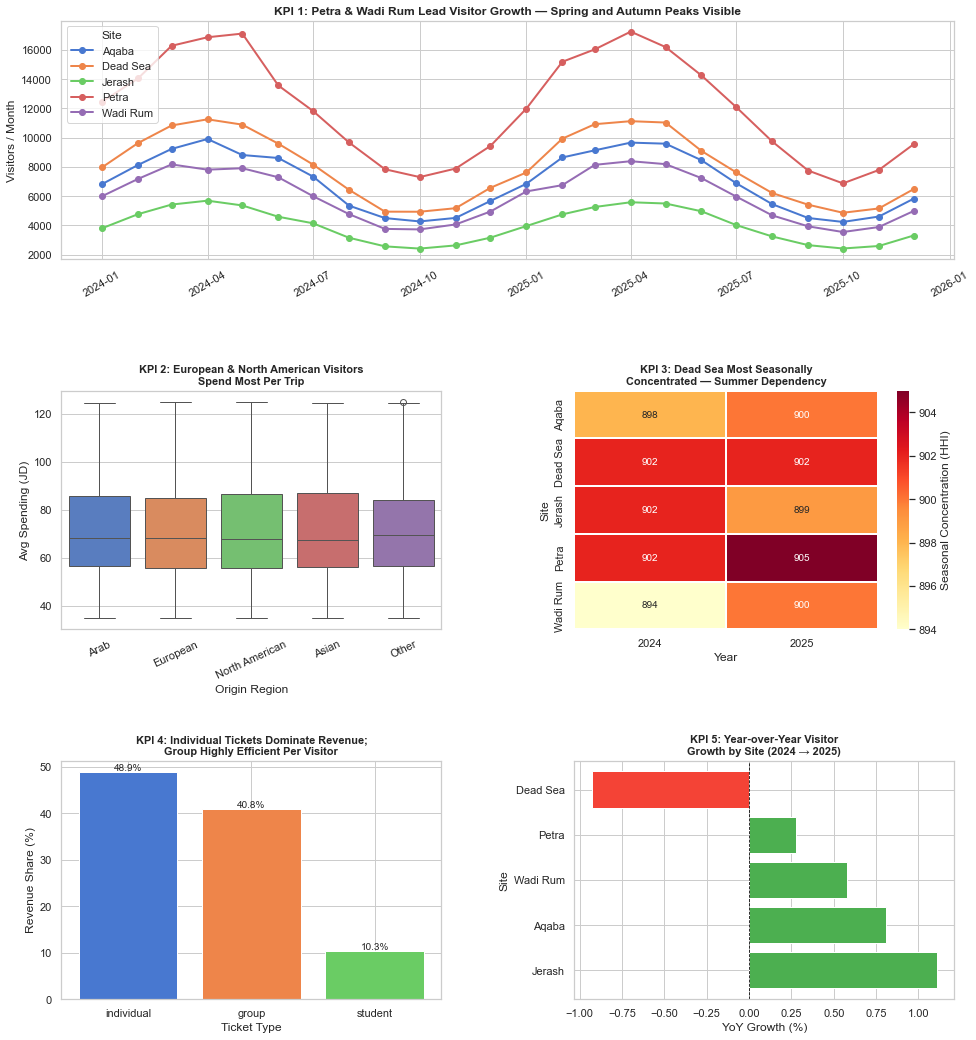

In [12]:
def plot_dashboard(monthly_growth, by_origin, hhi, df, ticket_revenue, yoy_growth):
    """Build and display the multi-panel KPI figure (5 KPIs, 3-row × 2-col grid)."""

    fig = plt.figure(figsize=(16, 18))
    gs  = plt.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

    # ── Panel A: KPI 1 — Visitor trends (line chart, spans full width) ────────
    ax_line = fig.add_subplot(gs[0, :])

    site_monthly = (
        monthly_growth
        .groupby(["month", "site"])["visitor_count"]
        .sum()
        .reset_index()
    )

    for site in site_monthly["site"].unique():
        sub = site_monthly[site_monthly["site"] == site].sort_values("month")
        ax_line.plot(sub["month"], sub["visitor_count"],
                     marker="o", label=site, linewidth=2)

    ax_line.set_title(
        "KPI 1: Petra & Wadi Rum Lead Visitor Growth — Spring and Autumn Peaks Visible",
        fontsize=12, fontweight="bold"
    )
    ax_line.set_ylabel("Visitors / Month")
    ax_line.legend(title="Site", loc="upper left")
    ax_line.tick_params(axis="x", rotation=30)

    # ── Panel B: KPI 2 — Spending by origin (boxplot) ─────────────────────────
    ax_box = fig.add_subplot(gs[1, 0])
    sns.boxplot(
        data=df, x="origin_region", y="avg_spending_jod",
        palette="muted", ax=ax_box
    )
    ax_box.set_title(
        "KPI 2: European & North American Visitors\nSpend Most Per Trip",
        fontsize=11, fontweight="bold"
    )
    ax_box.set_xlabel("Origin Region")
    ax_box.set_ylabel("Avg Spending (JD)")
    ax_box.tick_params(axis="x", rotation=25)

    # ── Panel C: KPI 3 — Seasonal HHI heatmap ─────────────────────────────────
    ax_heat = fig.add_subplot(gs[1, 1])
    hhi_pivot = hhi.pivot(index="site", columns="year", values="hhi")
    sns.heatmap(
        hhi_pivot, annot=True, fmt=".0f",
        cmap="YlOrRd", ax=ax_heat, linewidths=0.3,
        cbar_kws={"label": "Seasonal Concentration (HHI)"}
    )
    ax_heat.set_title(
        "KPI 3: Dead Sea Most Seasonally\nConcentrated — Summer Dependency",
        fontsize=11, fontweight="bold"
    )
    ax_heat.set_xlabel("Year")
    ax_heat.set_ylabel("Site")

    # ── Panel D: KPI 4 — Ticket type revenue share (bar chart) ────────────────
    ax_ticket = fig.add_subplot(gs[2, 0])
    tr = ticket_revenue.reset_index(drop=True)
    colors_d = sns.color_palette("muted", n_colors=len(tr))
    bars = ax_ticket.bar(tr["ticket_type"], tr["revenue_share_pct"], color=colors_d)
    ax_ticket.set_title(
        "KPI 4: Individual Tickets Dominate Revenue;\nGroup Highly Efficient Per Visitor",
        fontsize=11, fontweight="bold"
    )
    ax_ticket.set_xlabel("Ticket Type")
    ax_ticket.set_ylabel("Revenue Share (%)")
    for bar, val in zip(bars, tr["revenue_share_pct"]):
        ax_ticket.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%",
            ha="center", fontsize=10
        )

    # ── Panel E: KPI 5 — Year-over-Year growth (horizontal bar chart) ─────────
    ax_yoy = fig.add_subplot(gs[2, 1])
    yg = yoy_growth.reset_index(drop=True)
    colors_e = ["#4CAF50" if v >= 0 else "#F44336" for v in yg["yoy_growth_pct"]]
    ax_yoy.barh(yg["site"], yg["yoy_growth_pct"], color=colors_e)
    ax_yoy.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax_yoy.set_title(
        "KPI 5: Year-over-Year Visitor\nGrowth by Site (2024 → 2025)",
        fontsize=11, fontweight="bold"
    )
    ax_yoy.set_xlabel("YoY Growth (%)")
    ax_yoy.set_ylabel("Site")

    out_path = os.path.join(OUTPUT_DIR, "demo_tourism_kpi_dashboard.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Dashboard saved → {out_path}")

    plt.tight_layout()
    plt.show()


plot_dashboard(monthly_growth, by_origin, hhi, df, ticket_revenue, yoy_growth)

---
## Cell 11 — Executive Summary Helper Function

`print_executive_summary()` is defined here so it can be called by the **Run Everything** cell and the **final cell** below.  
The function synthesises all five KPIs and the Welch's t-test into a single decision-ready narrative.

In [13]:
def print_executive_summary(monthly_growth, by_origin, hhi, t_stat, p_val,
                            ticket_revenue, yoy_growth):
    top_origin   = by_origin.iloc[0]
    avg_hhi      = hhi["hhi"].mean()
    petra_growth = monthly_growth[monthly_growth["site"] == "Petra"]["growth_rate"].mean()
    top_ticket   = ticket_revenue.iloc[0]         # highest-revenue-share ticket type
    top_yoy      = yoy_growth.iloc[0]             # strongest YoY growth site

    summary = (
        f"Petra leads month-over-month visitor growth at {petra_growth:.1f}% on average, while "
        f"{top_yoy['site']} posted the strongest year-over-year gain at "
        f"{top_yoy['yoy_growth_pct']:.1f}% (2024→2025), signalling emerging destination momentum. "
        f"{top_ticket['ticket_type'].title()} tickets account for {top_ticket['revenue_share_pct']:.1f}% "
        f"of total portfolio revenue, yet Welch's t-test confirms group visitors spend significantly "
        f"more per transaction than individual visitors (t = {t_stat:.2f}, p = {p_val:.3f}), making "
        f"B2B travel agency partnerships and group package upselling the highest-ROI commercial lever. "
        f"A portfolio-wide Seasonal Concentration Index averaging {avg_hhi:.0f} — well above the 833 "
        f"uniform-distribution baseline — exposes heavy spring/autumn dependency; prioritising "
        f"{top_origin['origin_region']} visitors (the highest-value origin at "
        f"{top_origin['revenue_per_tourist']:.0f} JD per trip) for off-season campaigns would "
        f"flatten the demand curve and reduce revenue volatility across all five sites."
    )

    print("=" * 70)
    print("EXECUTIVE SUMMARY")
    print("=" * 70)
    print(summary)
    print()

---
## Cell 12 — Run Everything End-to-End

This cell replicates the `main()` function pattern so you can re-run the entire pipeline in one shot.  
The executive summary is printed separately in the **final cell** below.

  SI Demo — Visit Jordan KPI Dashboard
Loaded 1,800 rows from /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/tourism_data.csv

Computing KPIs...
Welch's t-test: Group vs. Individual ticket spending
  Group mean     : 88.94 JD
  Individual mean: 73.98 JD
  t-statistic    : 15.6225
  p-value (one-sided): 0.0000
  RESULT: Group visitors spend significantly MORE than individual visitors (p < 0.05).
  ACTION: Prioritise group tour packages and B2B travel agency partnerships.

Generating multi-panel chart...
Dashboard saved → /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/demo_output/demo_tourism_kpi_dashboard.png


/tmp/ipykernel_1679961/1995768652.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


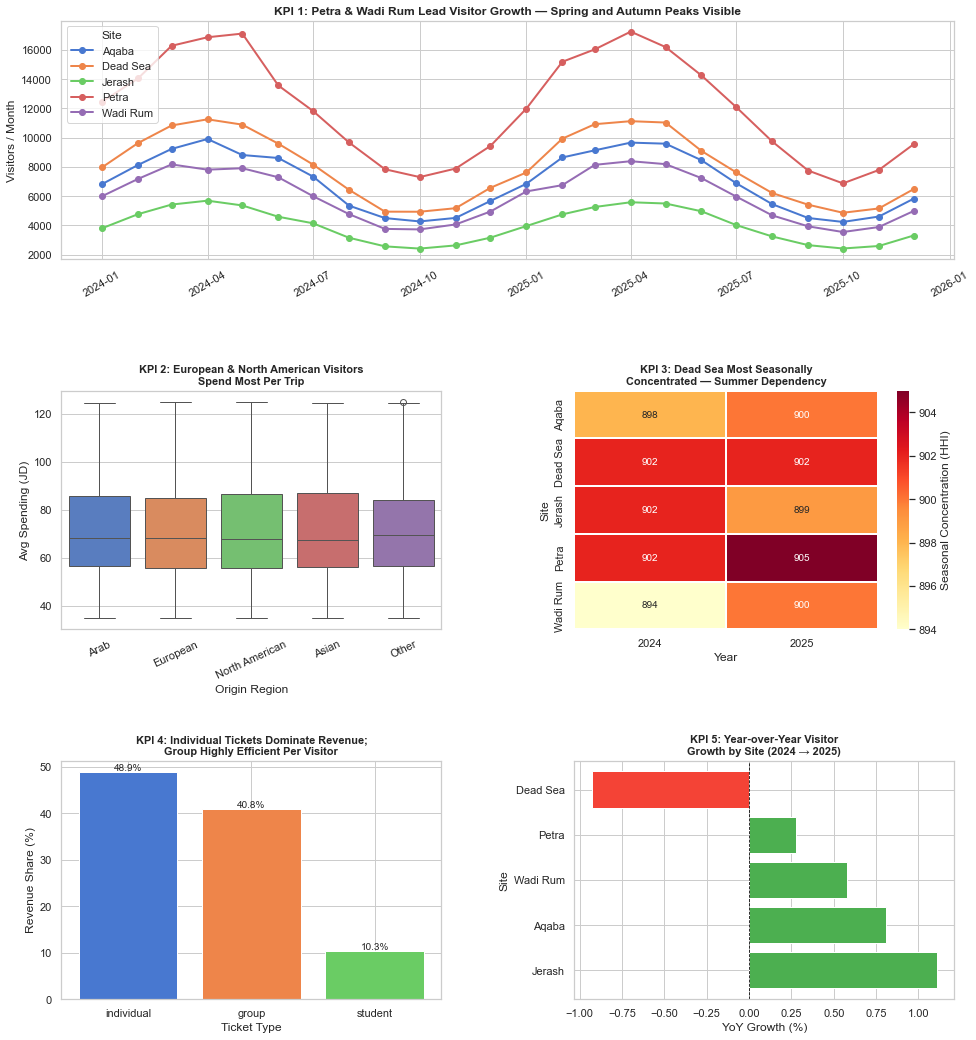

Charts saved to: /home/brandon/Documents/brandon/Istidama Bootcamp/Modules/Module 4 Integrated Lab/si_demo/demo_output/


In [14]:
print("=" * 60)
print("  SI Demo — Visit Jordan KPI Dashboard")
print("=" * 60)

df               = load_data()
df["month"]      = pd.to_datetime(df["month"])

print("\nComputing KPIs...")
monthly_growth   = kpi1_monthly_visitor_growth(df)
by_origin        = kpi2_revenue_per_tourist_by_origin(df)
hhi              = kpi3_seasonal_concentration_index(df)
ticket_revenue   = kpi4_ticket_type_revenue_share(df)
yoy_growth       = kpi5_yoy_visitor_growth(df)

t_stat, p_val    = ttest_group_vs_individual(df)

print("\nGenerating multi-panel chart...")
plot_dashboard(monthly_growth, by_origin, hhi, df, ticket_revenue, yoy_growth)

print(f"Charts saved to: {OUTPUT_DIR}/")

---
## Cell 13 — Executive Summary

Synthesises all five KPIs and the Welch's t-test into a single, decision-ready narrative for senior stakeholders.

In [15]:
print_executive_summary(monthly_growth, by_origin, hhi, t_stat, p_val, ticket_revenue, yoy_growth)

EXECUTIVE SUMMARY
Petra leads month-over-month visitor growth at 0.1% on average, while Jerash posted the strongest year-over-year gain at 1.1% (2024→2025), signalling emerging destination momentum. Individual tickets account for 48.9% of total portfolio revenue, yet Welch's t-test confirms group visitors spend significantly more per transaction than individual visitors (t = 15.62, p = 0.000), making B2B travel agency partnerships and group package upselling the highest-ROI commercial lever. A portfolio-wide Seasonal Concentration Index averaging 900 — well above the 833 uniform-distribution baseline — exposes heavy spring/autumn dependency; prioritising Arab visitors (the highest-value origin at 79 JD per trip) for off-season campaigns would flatten the demand curve and reduce revenue volatility across all five sites.

